# **Imports**

In [1]:
from importlib.metadata import Distribution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

# **Data Loading and Initial Exploration**

#### Loading the dataset and showing first 10 values

In [2]:
df = pd.read_csv('../data/data.csv')

In [3]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


#### **Dataset Shape**

In [4]:
print(df.shape)

(7043, 21)


#### Names of columns

In [5]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


#### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Summary statistics for numerical columns:

In [7]:
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### Summary statistics for categorical columns:

In [8]:
display(df.describe(include="object"))

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# **Missing Value Analysis**

#### Null value counts for all columns

In [9]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


#### Check for Hidden Missingness

In [10]:
blankCharges = df["TotalCharges"].astype(str).str.strip().eq("")
df.loc[blankCharges, ["customerID", "TotalCharges"]]

,customerID,TotalCharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


As we can see there are 11 entries with TotalCharges left blank even though scriptt didn't count them as missing

#### Missing values Visualization

<Axes: >

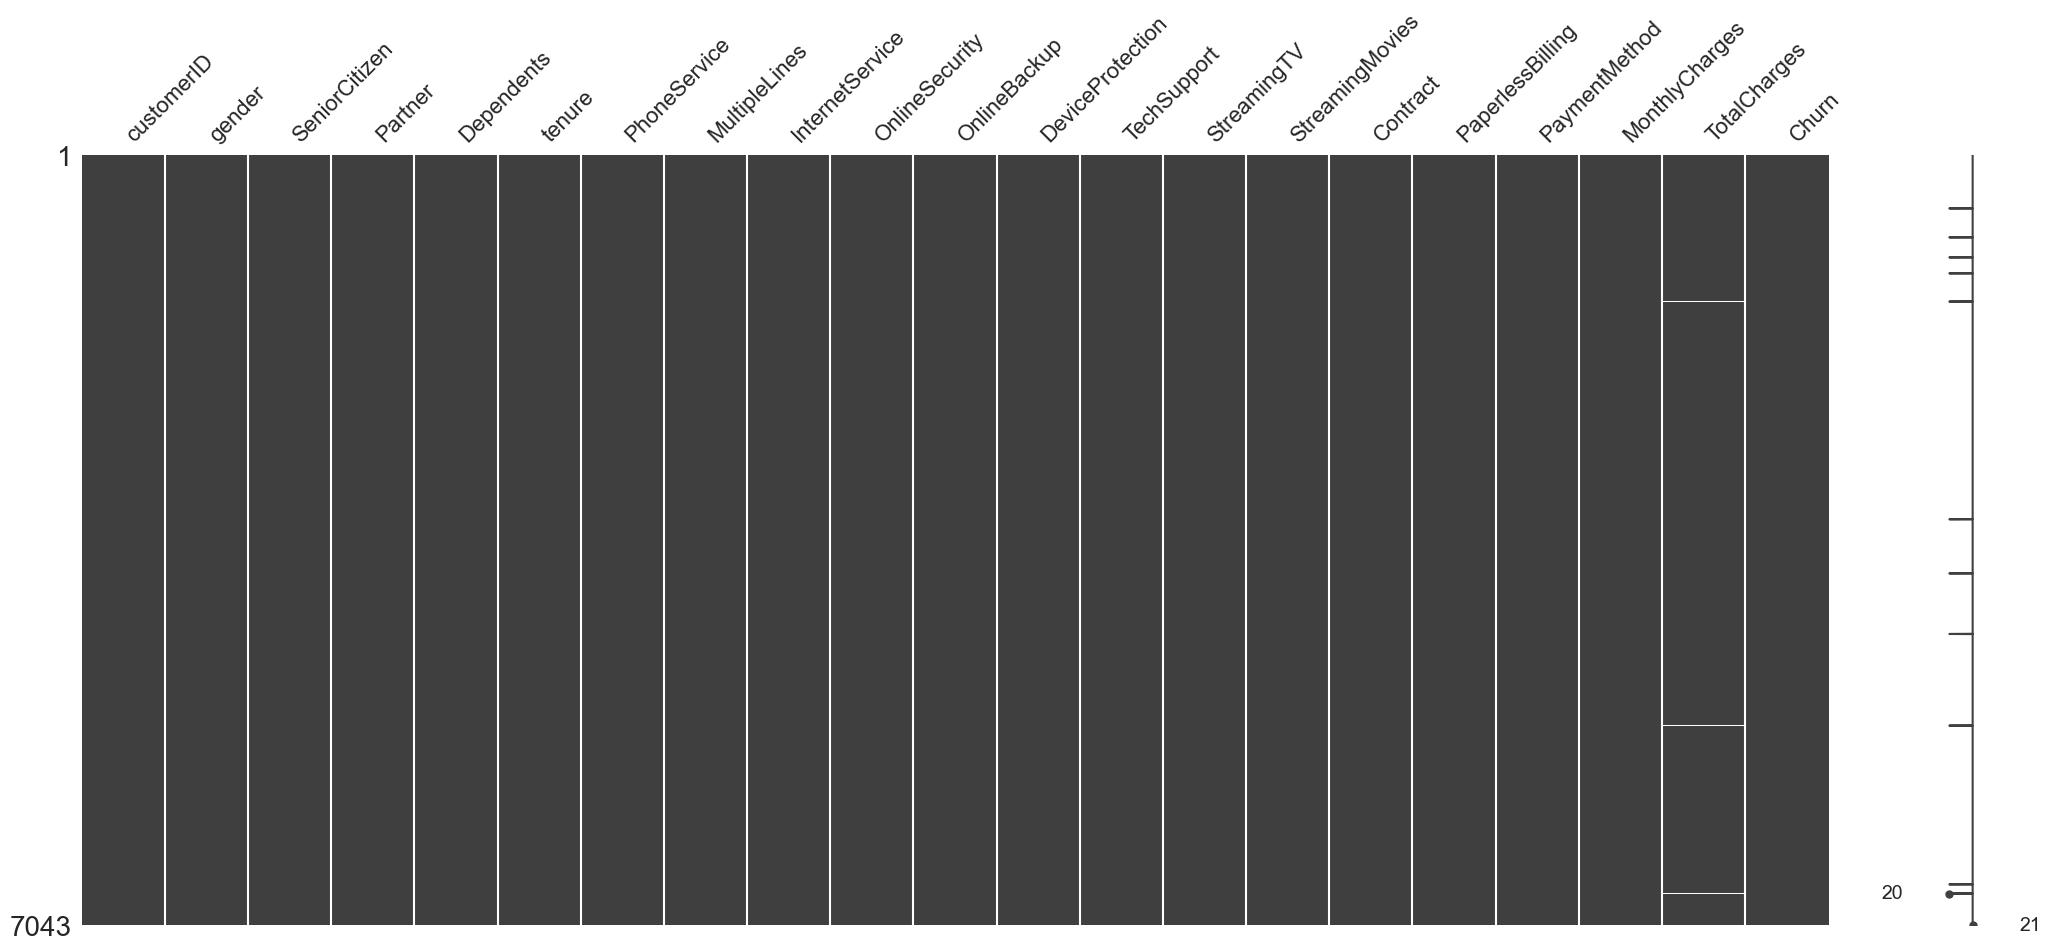

In [11]:
df_missing = df.copy()
df_missing.loc[df_missing["TotalCharges"].astype(str).str.strip().eq(""), "TotalCharges"] = np.nan
msno.matrix(df_missing)

# **Data Cleaning**

#### Dropping "customerID", because its an irrelevant identifier

In [12]:
df = df.drop(columns="customerID")

#### Converting TotalCharges to numeric, turning blank/whitespace values into NaN

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True))

#### Removing rows where tenure is 0

In [14]:
initVal = df.shape[0]
df = df[df["tenure"] != 0].copy()
afterVal = df.shape[0]
print(f"{initVal-afterVal} rows were removed")

11 rows were removed


#### Filling remaining TotalCharges NaNs with the column mean

In [15]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

#### Remaping SeniorCitizen from 0/1 to No/Yes

In [16]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

#### Checking dataset after the changes

In [17]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# **Exploratory Data Analysis (EDA)**

In [18]:
from pathlib import Path

plot_dir = Path('../plots')
plot_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', palette='Set2')
churn_palette = {'No': '#4C78A8', 'Yes': '#E45756'}


## **5a. Churn Distribution**

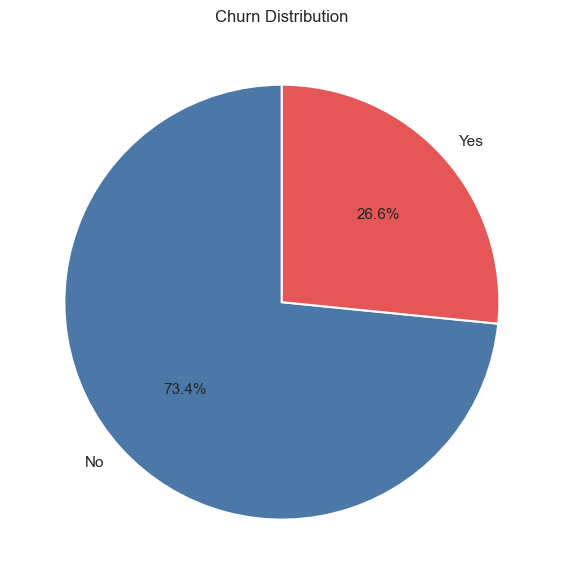

In [19]:
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts().reindex(['No', 'Yes'])
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[churn_palette['No'], churn_palette['Yes']],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11},
)
plt.title('Churn Distribution')
plt.tight_layout()
plt.savefig(plot_dir / 'churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


Most customers stay with the company: about 73.4% are in the `No` churn class, while 26.6% have churned. The class imbalance is noticeable and should be kept in mind during modeling.

## **5b. Demographics**

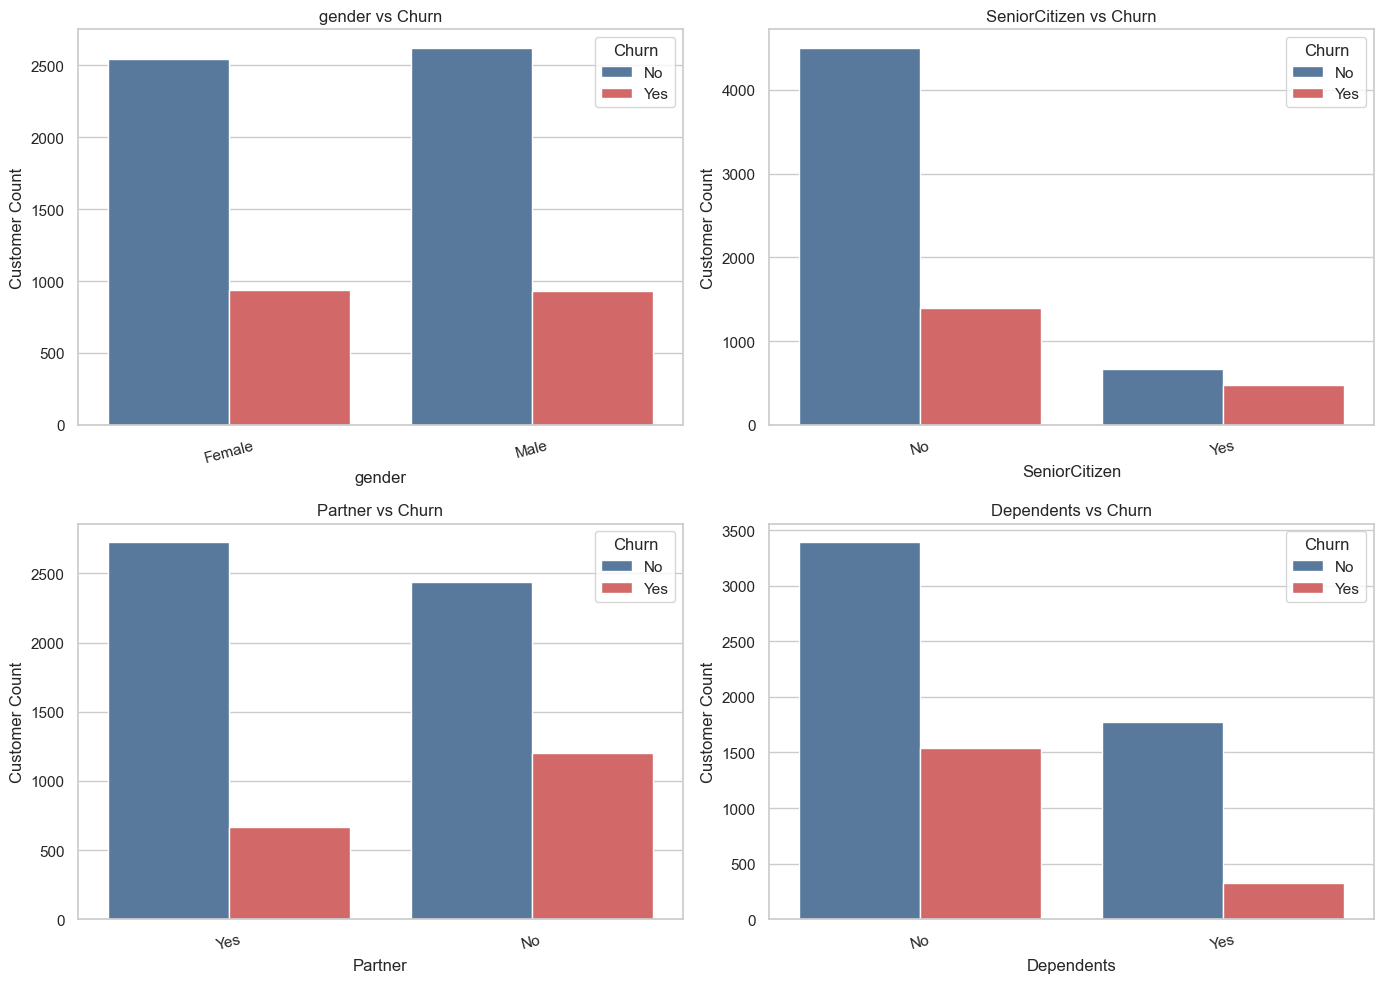

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
demographic_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for ax, column in zip(axes.flatten(), demographic_cols):
    sns.countplot(data=df, x=column, hue='Churn', palette=churn_palette, ax=ax)
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=15)

fig.tight_layout()
fig.savefig(plot_dir / 'demographics_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()


Gender is fairly balanced and shows very similar churn behavior across groups. Churn is visibly higher among senior citizens, customers without partners, and customers without dependents.

## **5c. Contract & Payment**

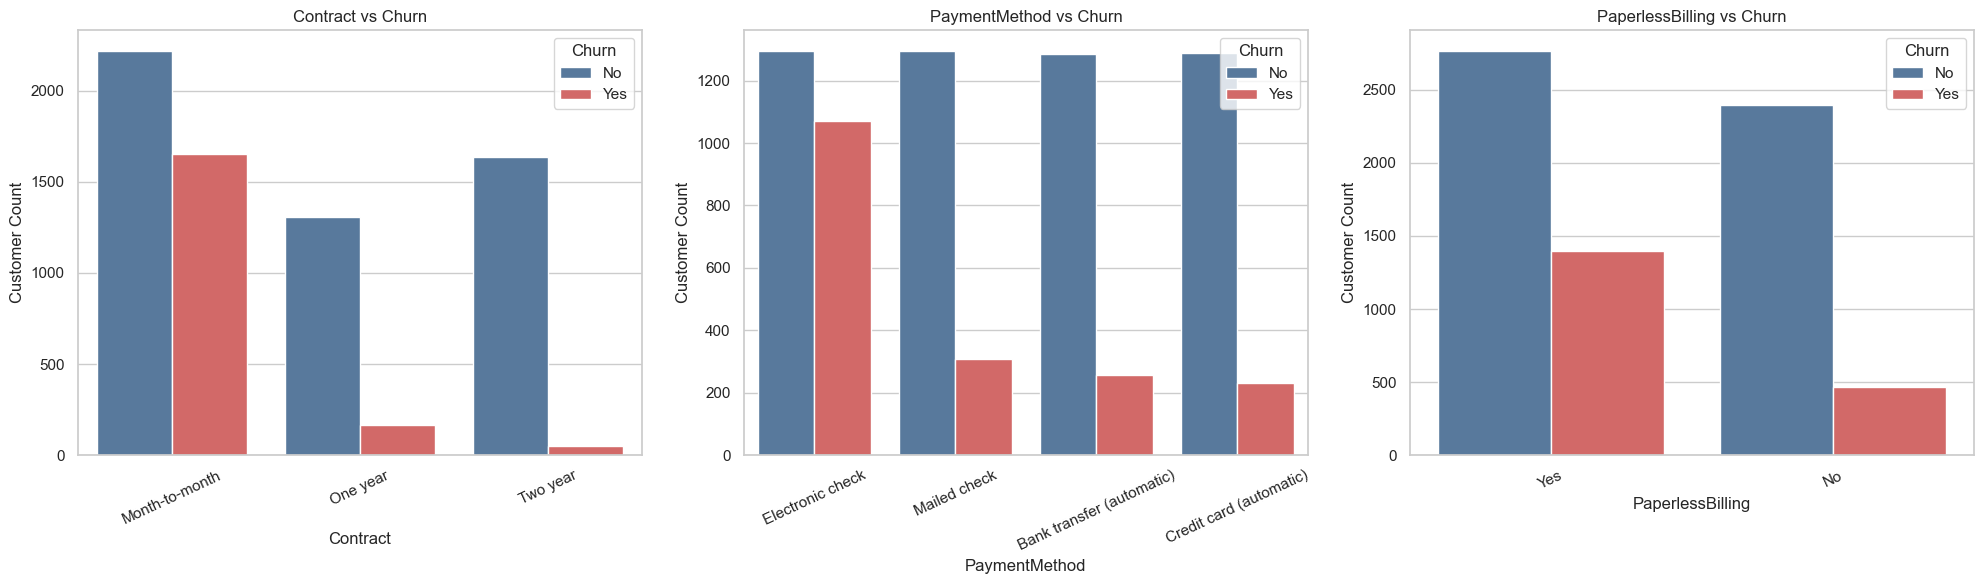

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
contract_payment_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']

for ax, column in zip(axes.flatten(), contract_payment_cols):
    sns.countplot(data=df, x=column, hue='Churn', palette=churn_palette, ax=ax)
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=25)

fig.tight_layout()
fig.savefig(plot_dir / 'contract_payment_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()


Month-to-month customers churn much more often than customers on one-year or two-year contracts. Electronic check and paperless billing users also show a noticeably larger churn segment.

## **5d. Internet & Add-on Services**

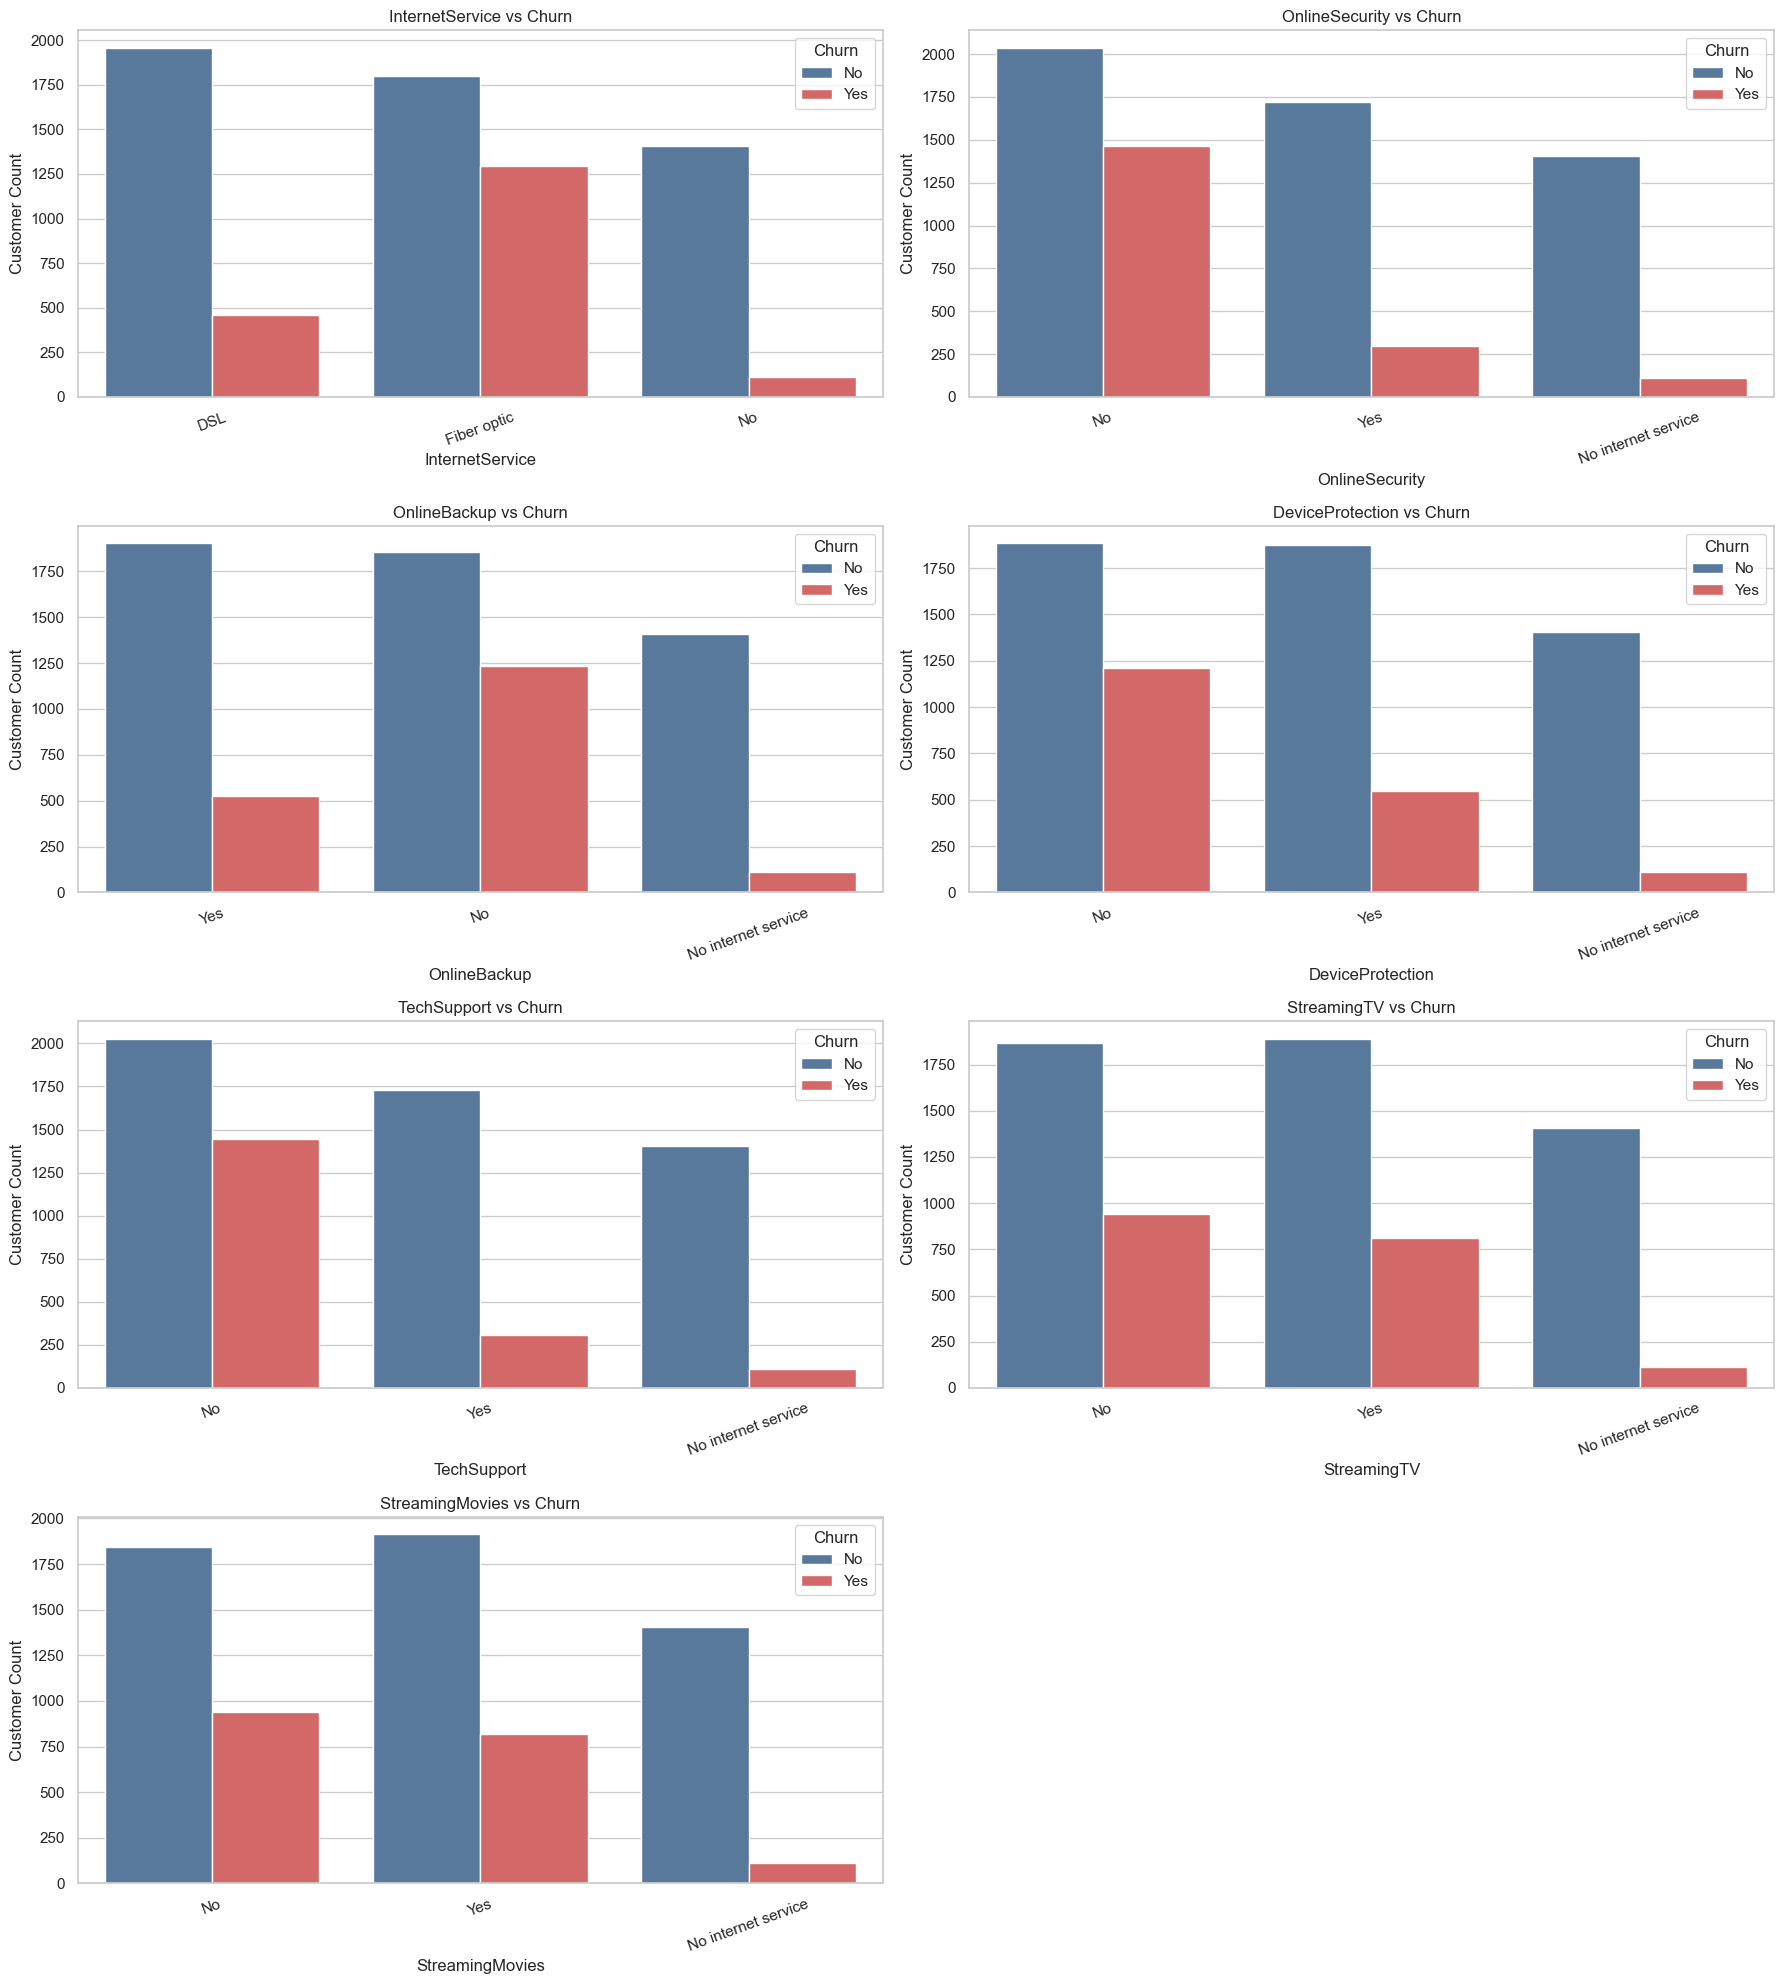

In [22]:
service_cols = [
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
]

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
for ax, column in zip(axes.flatten(), service_cols):
    sns.countplot(data=df, x=column, hue='Churn', palette=churn_palette, ax=ax)
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Customer Count')
    ax.tick_params(axis='x', rotation=20)

axes.flatten()[-1].axis('off')
fig.tight_layout()
fig.savefig(plot_dir / 'internet_addon_services_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()


Fiber optic customers have the largest churn segment, while customers with no internet service churn the least. Add-on protections such as online security and tech support are associated with visibly lower churn.

## **5e. Numerical Distributions**

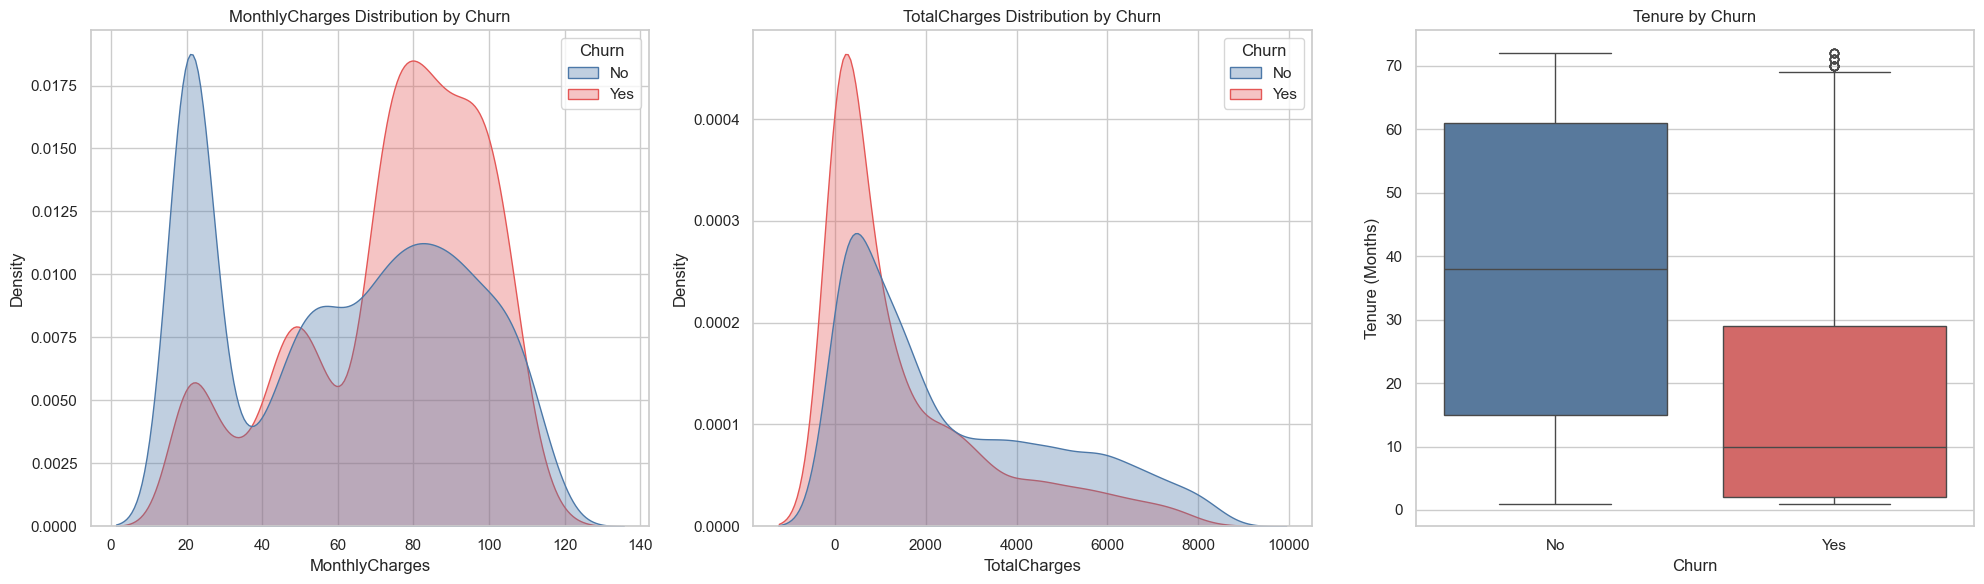

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, column in zip(axes[:2], ['MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(
        data=df,
        x=column,
        hue='Churn',
        fill=True,
        common_norm=False,
        palette=churn_palette,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f'{column} Distribution by Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Density')

sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette=churn_palette, dodge=False, legend=False, ax=axes[2])
axes[2].set_title('Tenure by Churn')
axes[2].set_xlabel('Churn')
axes[2].set_ylabel('Tenure (Months)')

fig.tight_layout()
fig.savefig(plot_dir / 'numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


Customers who churn tend to have higher monthly charges but much shorter tenure. Total charges are generally lower for churned customers, which is consistent with them leaving earlier.

## **5f. Correlation Heatmap**

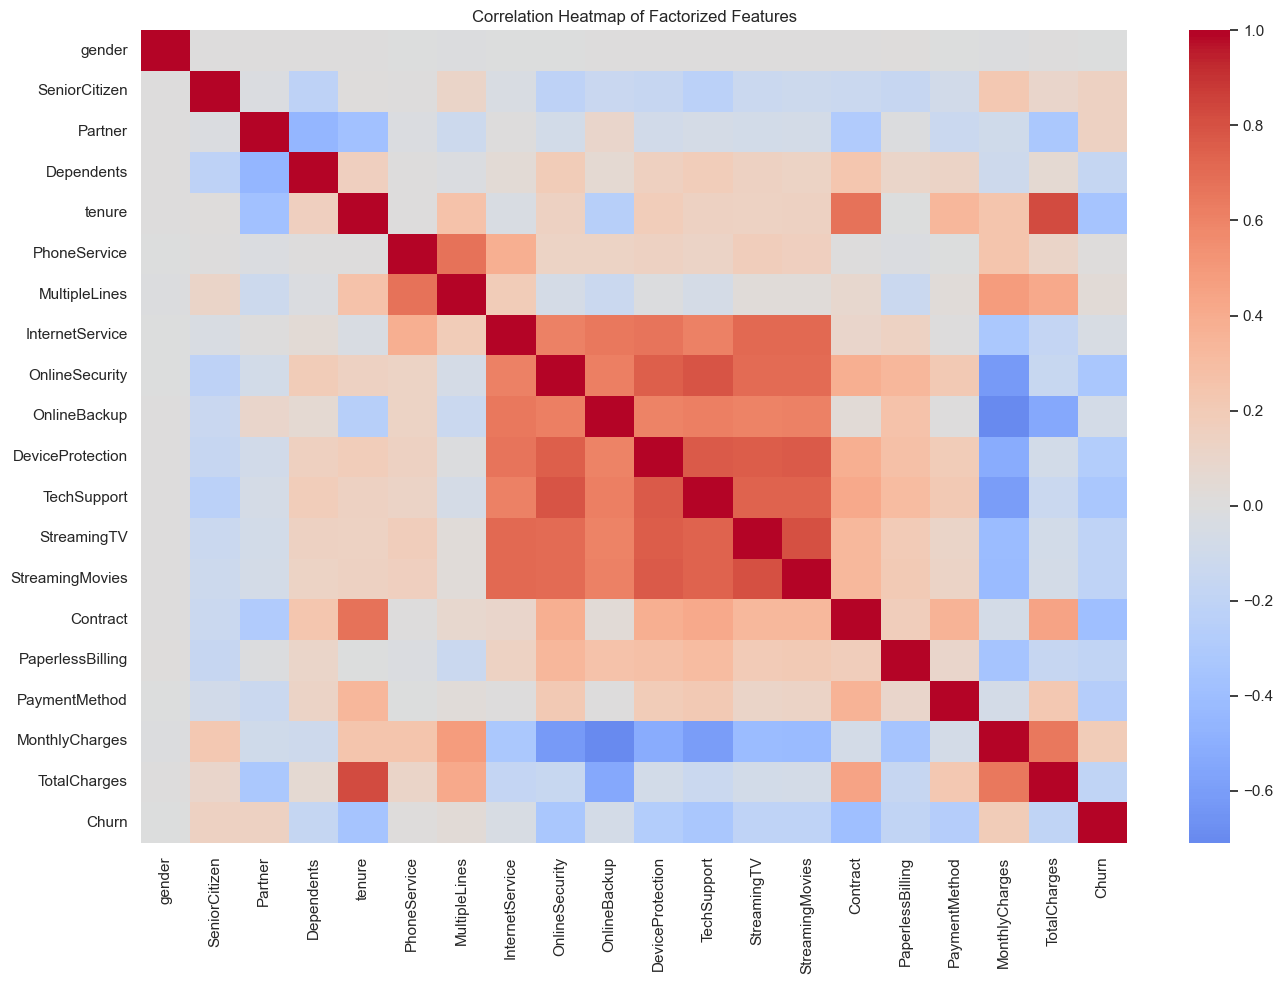

In [24]:
corr_df = df.copy()
for column in corr_df.select_dtypes(include='object').columns:
    corr_df[column], _ = pd.factorize(corr_df[column])

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Factorized Features')
plt.tight_layout()
plt.savefig(plot_dir / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


The heatmap shows that contract type, tenure, and total charges move together more strongly than most other features. Churn also appears more aligned with short contracts and weaker service-commitment related features than with demographic variables.

# **Data Preprocessing**

#### Encoding helper

In [25]:
def encode_data(dataframe: pd.DataFrame) -> pd.DataFrame:
    categorical_cols = dataframe.select_dtypes(include='object').columns.tolist()
    categorical_cols = [col for col in categorical_cols if col != 'Churn']
    return pd.get_dummies(dataframe, columns=categorical_cols, drop_first=False, dtype=int)


One-hot encoding is used here because most categorical features are nominal, and this avoids introducing artificial order between categories.

#### Split features and target

In [26]:
df_model = encode_data(df.copy())
df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1})

X = df_model.drop(columns='Churn')
y = df_model['Churn']

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (7032, 46)
y shape: (7032,)


#### Train / Validation / Test split

In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1712,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=1712,
    stratify=y_temp,
)

print('Train shape:', X_train.shape, y_train.shape)
print('Validation shape:', X_val.shape, y_val.shape)
print('Test shape:', X_test.shape, y_test.shape)


Train shape: (5625, 46) (5625,)
Validation shape: (703, 46) (703,)
Test shape: (704, 46) (704,)


This two-step split gives an effective 80/10/10 partition while keeping the churn ratio balanced across all three sets.

#### Feature scaling

In [28]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print('Scaled train shape:', X_train_scaled.shape)
print('Scaled validation shape:', X_val_scaled.shape)
print('Scaled test shape:', X_test_scaled.shape)


Scaled train shape: (5625, 46)
Scaled validation shape: (703, 46)
Scaled test shape: (704, 46)


`StandardScaler` is fitted only on the training set, then reused on validation and test data so information from holdout sets does not leak into preprocessing.

# **Model Training & Evaluation**

#### Reusable evaluation helper

In [29]:
def evaluate_model(model, model_name, X_eval, y_eval):
    y_pred = model.predict(X_eval)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_eval)
    else:
        raise ValueError(f'{model_name} does not provide probability scores for ROC-AUC evaluation.')

    print(f'=== {model_name} ===')
    print(classification_report(y_eval, y_pred))

    roc_auc = roc_auc_score(y_eval, y_score)
    print(f'ROC-AUC Score: {roc_auc:.4f}')

    model_slug = model_name.lower().replace(' ', '_').replace('-', '_')

    cm = confusion_matrix(y_eval, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn']).plot(
        cmap='Blues',
        ax=ax,
        colorbar=False,
    )
    ax.set_title(f'{model_name} Confusion Matrix')
    fig.tight_layout()
    fig.savefig(plot_dir / f'{model_slug}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    fpr, tpr, _ = roc_curve(y_eval, y_score)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}', color='#E45756', linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f'{model_name} ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    fig.tight_layout()
    fig.savefig(plot_dir / f'{model_slug}_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'Model': model_name,
        'ROC-AUC': roc_auc,
    }


The models below are trained on `X_train_scaled` / `y_train` and evaluated on the validation split so they can be compared consistently before any final test-set check.

#### Logistic Regression

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       516
           1       0.72      0.58      0.64       187

    accuracy                           0.83       703
   macro avg       0.79      0.75      0.76       703
weighted avg       0.82      0.83      0.82       703

ROC-AUC Score: 0.8537


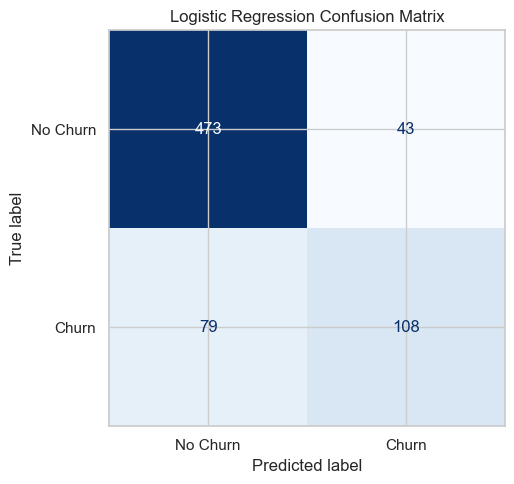

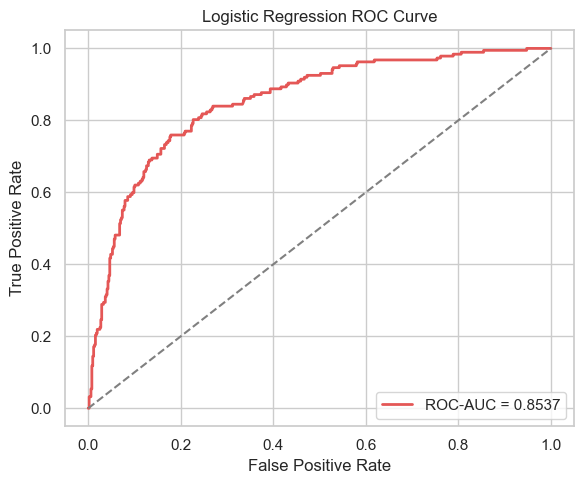

In [30]:
logistic_model = LogisticRegression(max_iter=1000, random_state=1712)
logistic_model.fit(X_train_scaled, y_train)
logistic_results = evaluate_model(logistic_model, 'Logistic Regression', X_val_scaled, y_val)


#### Decision Tree

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       516
           1       0.46      0.49      0.48       187

    accuracy                           0.71       703
   macro avg       0.64      0.64      0.64       703
weighted avg       0.72      0.71      0.72       703

ROC-AUC Score: 0.6429


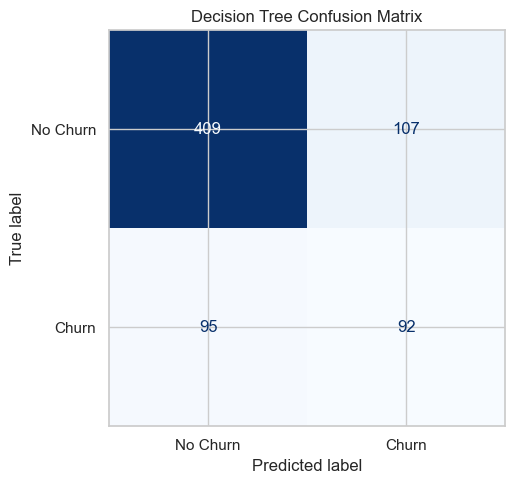

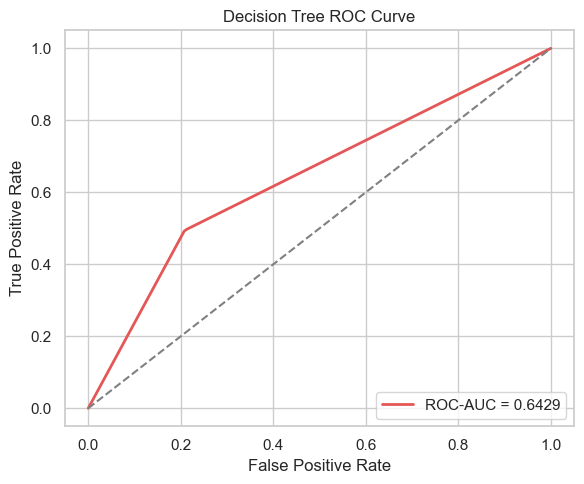

In [31]:
decision_tree_model = DecisionTreeClassifier(random_state=1712)
decision_tree_model.fit(X_train_scaled, y_train)
decision_tree_results = evaluate_model(decision_tree_model, 'Decision Tree', X_val_scaled, y_val)


#### Random Forest

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       516
           1       0.64      0.43      0.52       187

    accuracy                           0.78       703
   macro avg       0.73      0.67      0.69       703
weighted avg       0.77      0.78      0.77       703

ROC-AUC Score: 0.8165


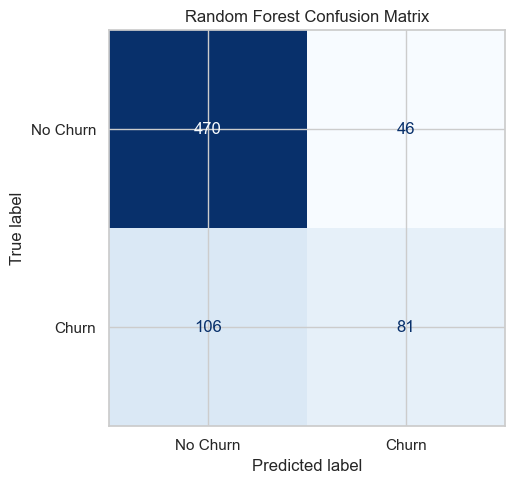

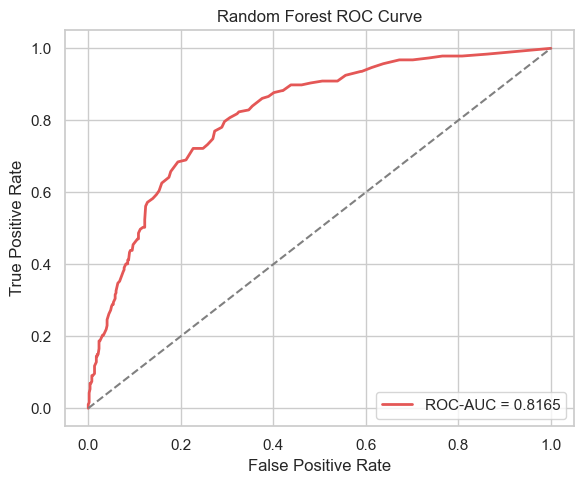

In [32]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=1712)
random_forest_model.fit(X_train_scaled, y_train)
random_forest_results = evaluate_model(random_forest_model, 'Random Forest', X_val_scaled, y_val)


#### XGBoost

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       516
           1       0.70      0.53      0.60       187

    accuracy                           0.81       703
   macro avg       0.77      0.72      0.74       703
weighted avg       0.80      0.81      0.80       703

ROC-AUC Score: 0.8509


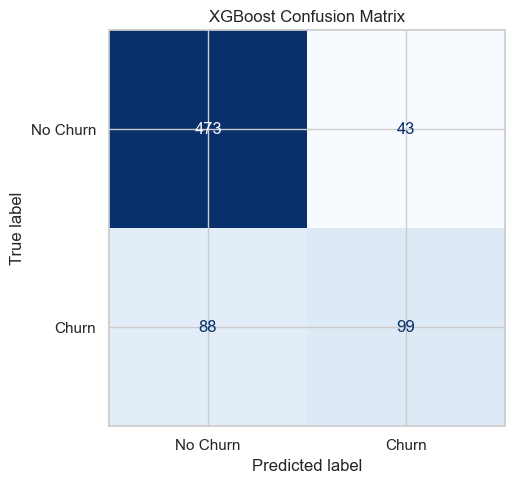

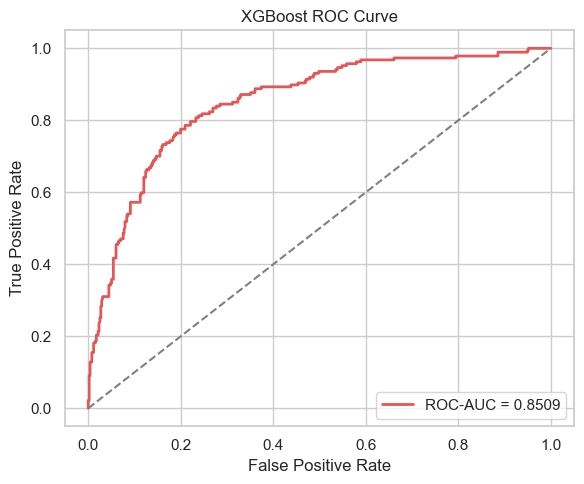

In [33]:
xgboost_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=1712,
    eval_metric='logloss',
)
xgboost_model.fit(X_train_scaled, y_train)
xgboost_results = evaluate_model(xgboost_model, 'XGBoost', X_val_scaled, y_val)


#### K-Nearest Neighbors

=== KNN ===
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       516
           1       0.61      0.55      0.58       187

    accuracy                           0.79       703
   macro avg       0.73      0.71      0.72       703
weighted avg       0.78      0.79      0.78       703

ROC-AUC Score: 0.8210


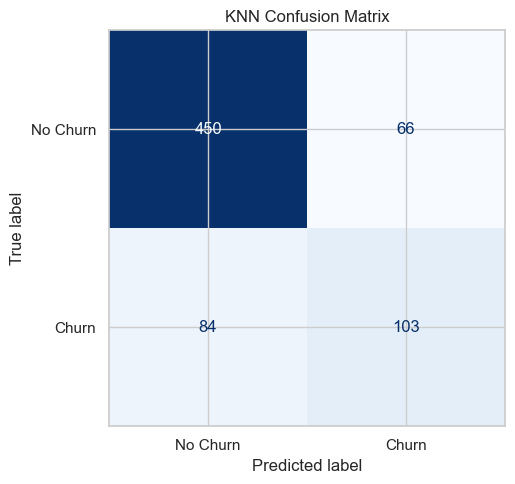

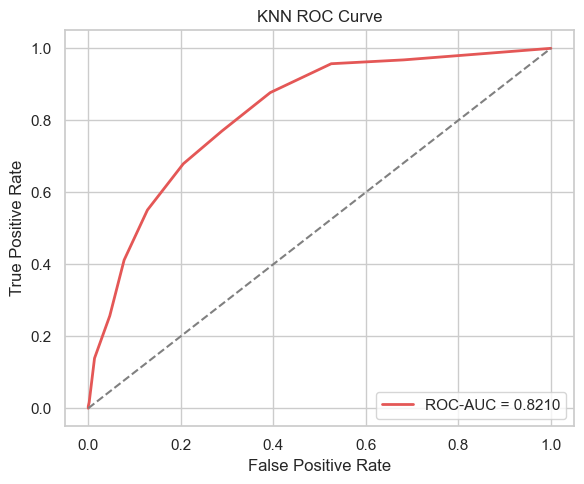

In [34]:
knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(X_train_scaled, y_train)
knn_results = evaluate_model(knn_model, 'KNN', X_val_scaled, y_val)


#### Validation summary

In [35]:
model_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    xgboost_results,
    knn_results,
]).sort_values(by='ROC-AUC', ascending=False)

model_comparison


,Model,ROC-AUC
0,Logistic Regression,0.853672
3,XGBoost,0.850915
4,KNN,0.820985
2,Random Forest,0.816477
1,Decision Tree,0.642950
